# Waveform-Based Group Results Review

이 노트북은 `data/processed/waveform_based`에 저장된 결과 파일을 불러와,
성인 `HA`, `ACLD`, `ACLR` 3그룹의 lower-limb 3-plane 각도 분석 결과를 검토한다.
핵심 목표는 다음과 같다.

- SPM1D의 omnibus / post-hoc 결과에서 어떤 관절-평면-속도 조합이 유의했는지 확인
- LMM에서 어떤 요약 feature가 그룹 차이와 속도 상호작용을 설명했는지 확인
- elastic-net ranking이 어떤 feature를 상위 설명 변수로 선택했는지 확인
- validation / sensitivity 결과를 통해 해석 시 주의점을 정리

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)

REPO = Path.cwd()
if not (REPO / 'data').exists():
    REPO = REPO.parent
RESULT_DIR = REPO / 'data' / 'processed' / 'waveform_based'
RESULT_DIR

PosixPath('/Users/ryutt/Desktop/mini_ryutt/Walking/data/processed/waveform_based')

In [2]:
wave = pd.read_csv(RESULT_DIR / 'subject_speed_waveforms.csv')
spm = pd.read_csv(RESULT_DIR / 'spm_results.csv')
feat = pd.read_csv(RESULT_DIR / 'feature_table.csv')
lmm = pd.read_csv(RESULT_DIR / 'lmm_results.csv')
rank = pd.read_csv(RESULT_DIR / 'feature_ranking.csv')
val = pd.read_csv(RESULT_DIR / 'validation_summary.csv')
sens = pd.read_csv(RESULT_DIR / 'sensitivity_comparison.csv')

{
    'wave_shape': wave.shape,
    'spm_shape': spm.shape,
    'feature_shape': feat.shape,
    'lmm_shape': lmm.shape,
    'ranking_shape': rank.shape,
    'validation_shape': val.shape,
    'sensitivity_shape': sens.shape,
}

{'wave_shape': (9828, 113),
 'spm_shape': (346, 26),
 'feature_shape': (273, 388),
 'lmm_shape': (504, 17),
 'ranking_shape': (44, 6),
 'validation_shape': (30, 5),
 'sensitivity_shape': (54, 10)}

## 1. Primary SPM 결과 요약
SPM1D는 속도별(`slow`, `normal`, `fast`)로 분리해 수행되었고,
각 속도에서 `injured` / `contralateral` side basis와 9개 joint-plane waveform을 비교했다.
아래 표는 full-trial 기준 FDR 유의 결과만 모은 것이다.

In [3]:
primary_sig = spm[(spm['analysis_variant'] == 'full') & (spm['comparison_scope'] == 'primary') & (spm['significant_fdr'])].copy()
primary_sig.groupby('test_type').size().rename('count').to_frame()

,count
test_type,
omnibus,27
posthoc,36


In [4]:
primary_sig.groupby(['speed', 'feature']).size().rename('significant_clusters').sort_values(ascending=False).to_frame().head(20)

significant_clusters
speed  feature                                 
fast   knee_flexion                          10
       knee_int_rotation                      8
       hip_adduction                          6
slow   knee_flexion                           6
fast   ankle_dorsiflexion                     5
normal knee_adduction                         5
fast   knee_adduction                         4
normal hip_adduction                          4
       knee_flexion                           4
slow   knee_adduction                         4
       hip_adduction                          3
fast   ankle_adduction                        2
normal ankle_adduction                        2

In [5]:
omnibus_sig = primary_sig[primary_sig['test_type'] == 'omnibus'][[
    'speed', 'side_basis', 'feature', 'test_p_fdr', 'start_pct', 'end_pct',
    'effect_size', 'ha_mean', 'acld_mean', 'aclr_mean'
]].sort_values(['test_p_fdr', 'speed', 'feature'])
omnibus_sig.head(30)

,speed,side_basis,feature,test_p_fdr,start_pct,end_pct,effect_size,ha_mean,acld_mean,aclr_mean
98,fast,injured,knee_flexion,0.001035,5.0,12.0,0.102457,19.355489,16.334463,14.268707
99,fast,injured,knee_flexion,0.001035,32.0,45.0,0.122231,6.276926,8.036989,10.698337
100,fast,injured,knee_flexion,0.001035,91.0,94.0,0.099167,1.797394,1.948259,5.212822
44,normal,injured,knee_adduction,0.001135,30.0,37.0,0.121561,-1.330658,-0.823918,-0.451024
45,normal,injured,knee_adduction,0.001135,75.0,86.0,0.182473,0.610026,-1.927358,-1.794601
12,slow,injured,knee_adduction,0.001135,15.0,40.0,0.147764,-1.188164,-0.584055,-0.324063
13,slow,injured,knee_adduction,0.001135,76.0,84.0,0.128448,0.851849,-1.596426,-1.128059
120,fast,contralateral,hip_adduction,0.001343,20.0,35.0,0.119340,-6.250387,-4.321988,-4.282760
121,fast,contralateral,hip_adduction,0.001343,67.0,84.0,0.154860,2.138711,4.959060,4.252453
133,fast,contralateral,knee_flexion,0.001343,50.0,60.0,0.110464,34.358852,32.519389,28.538439


In [6]:
posthoc_sig = primary_sig[primary_sig['test_type'] == 'posthoc'][[
    'speed', 'side_basis', 'feature', 'group_a', 'group_b', 'test_p_fdr',
    'start_pct', 'end_pct', 'effect_size', 'mean_diff'
]].sort_values(['test_p_fdr', 'speed', 'feature'])
posthoc_sig.head(40)

,speed,side_basis,feature,group_a,group_b,test_p_fdr,start_pct,end_pct,effect_size,mean_diff
15,slow,injured,knee_adduction,HA,ACLR,0.000001,15.0,40.0,-1.107396,-0.864101
20,slow,injured,knee_flexion,HA,ACLR,0.000001,0.0,1.0,-0.792983,-3.180578
21,slow,injured,knee_flexion,HA,ACLR,0.000001,26.0,47.0,-1.026561,-4.755867
22,slow,injured,knee_flexion,HA,ACLR,0.000001,74.0,82.0,0.864231,6.245637
23,slow,injured,knee_flexion,HA,ACLR,0.000001,94.0,99.0,-0.867705,-2.833923
107,fast,injured,knee_int_rotation,HA,ACLR,0.000226,17.0,32.0,-1.262137,-1.603873
108,fast,injured,knee_int_rotation,HA,ACLR,0.000226,77.0,85.0,1.163163,2.166531
47,normal,injured,knee_adduction,HA,ACLR,0.000226,29.0,38.0,-0.957129,-0.858674
48,normal,injured,knee_adduction,HA,ACLR,0.000226,76.0,86.0,1.069820,2.358307
136,fast,contralateral,knee_flexion,HA,ACLR,0.000793,48.0,59.0,0.963314,5.557180


## 2. 핵심 waveform 시각화
유의 결과가 반복적으로 나타난 feature를 골라, 그룹 평균 waveform을 속도별로 확인한다.
여기서는 `knee_flexion`, `knee_adduction`, `hip_adduction`, `ankle_dorsiflexion`을 확인한다.

In [7]:
POINT_COLS = [f'point_{i:03d}' for i in range(101)]
GROUP_ORDER = ['HA', 'ACLD', 'ACLR']
SPEED_ORDER = ['slow', 'normal', 'fast']
PALETTE = {'HA': '#1f77b4', 'ACLD': '#d62728', 'ACLR': '#2ca02c'}

def plot_feature_waveforms(feature, side_basis):
    sub = wave[(wave['analysis_variant'] == 'full') & (wave['feature'] == feature) & (wave['side_basis'] == side_basis)].copy()
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True, constrained_layout=True)
    for ax, speed in zip(axes, SPEED_ORDER):
        speed_sub = sub[sub['speed'] == speed]
        for group in GROUP_ORDER:
            g = speed_sub[speed_sub['group'] == group]
            if g.empty:
                continue
            arr = g[POINT_COLS].to_numpy(dtype=float)
            mean = arr.mean(axis=0)
            sem = arr.std(axis=0, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else np.zeros_like(mean)
            x = np.arange(101)
            ax.plot(x, mean, label=group, color=PALETTE[group], linewidth=2.5)
            ax.fill_between(x, mean - sem, mean + sem, color=PALETTE[group], alpha=0.18)
        ax.set_title(f'{feature} | {side_basis} | {speed}')
        ax.set_xlabel('Gait cycle (%)')
        ax.set_xlim(0, 100)
    axes[0].set_ylabel('Angle (deg)')
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
    plt.show()

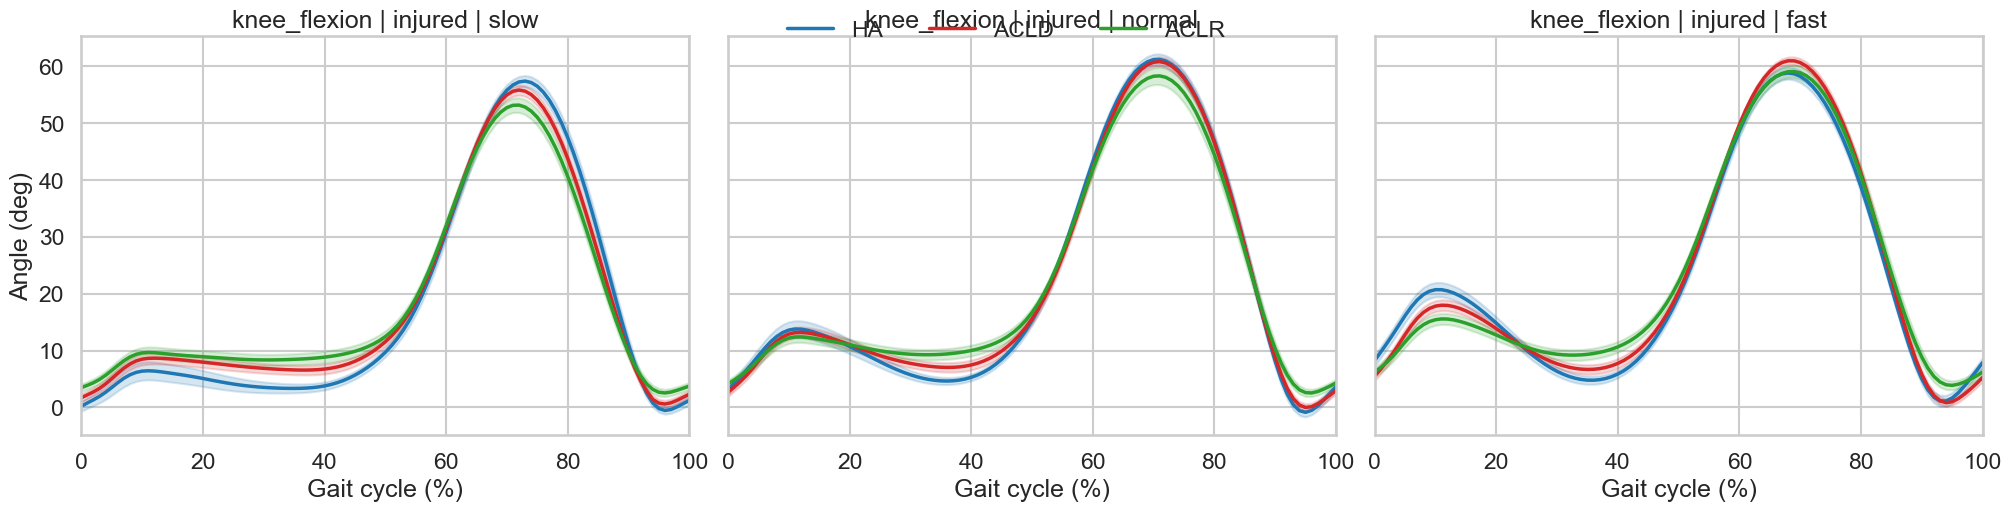

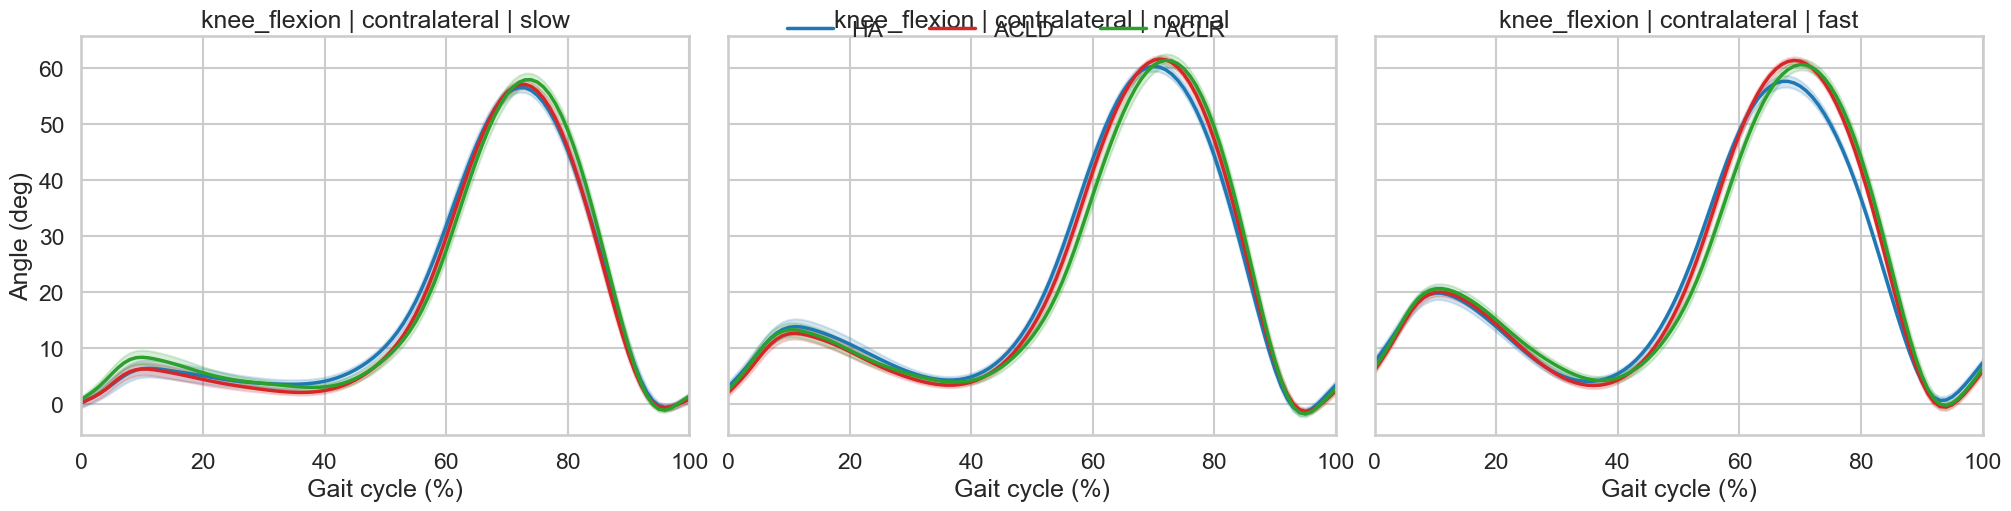

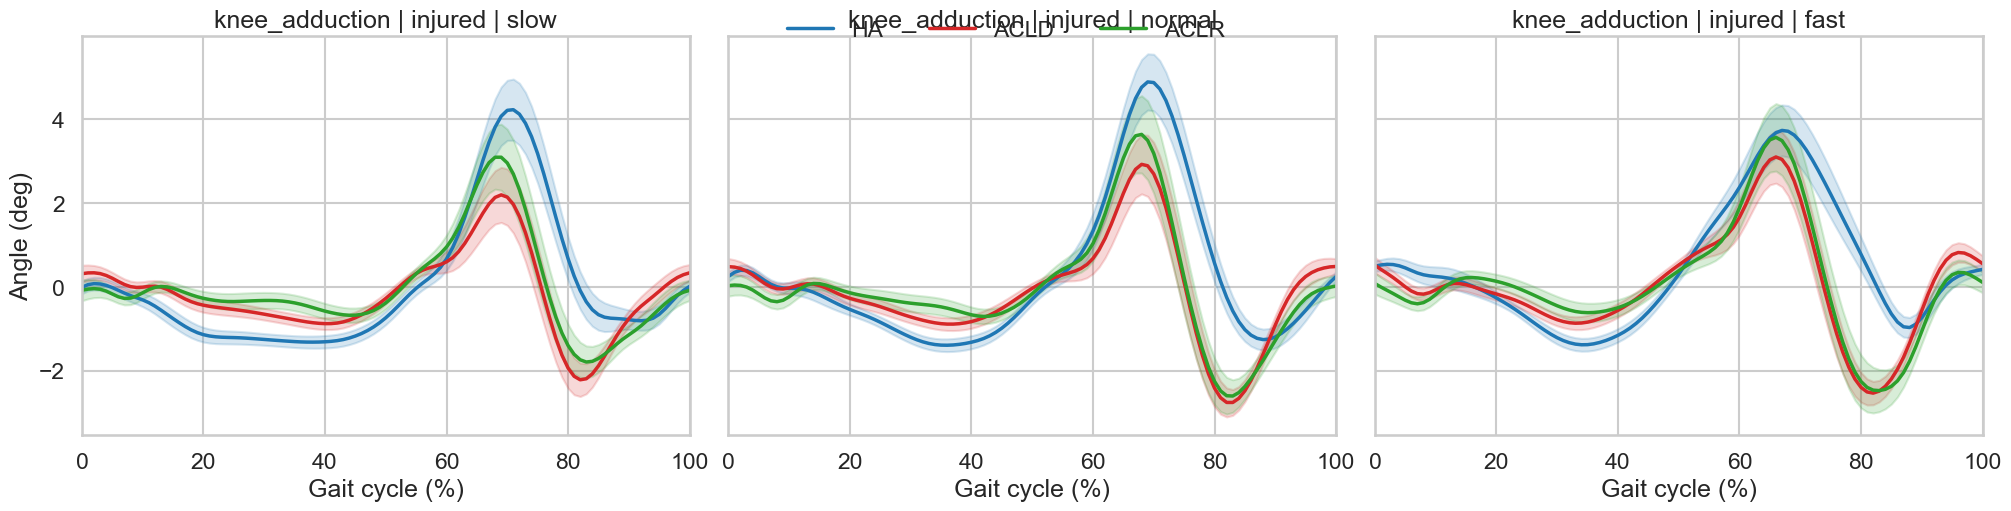

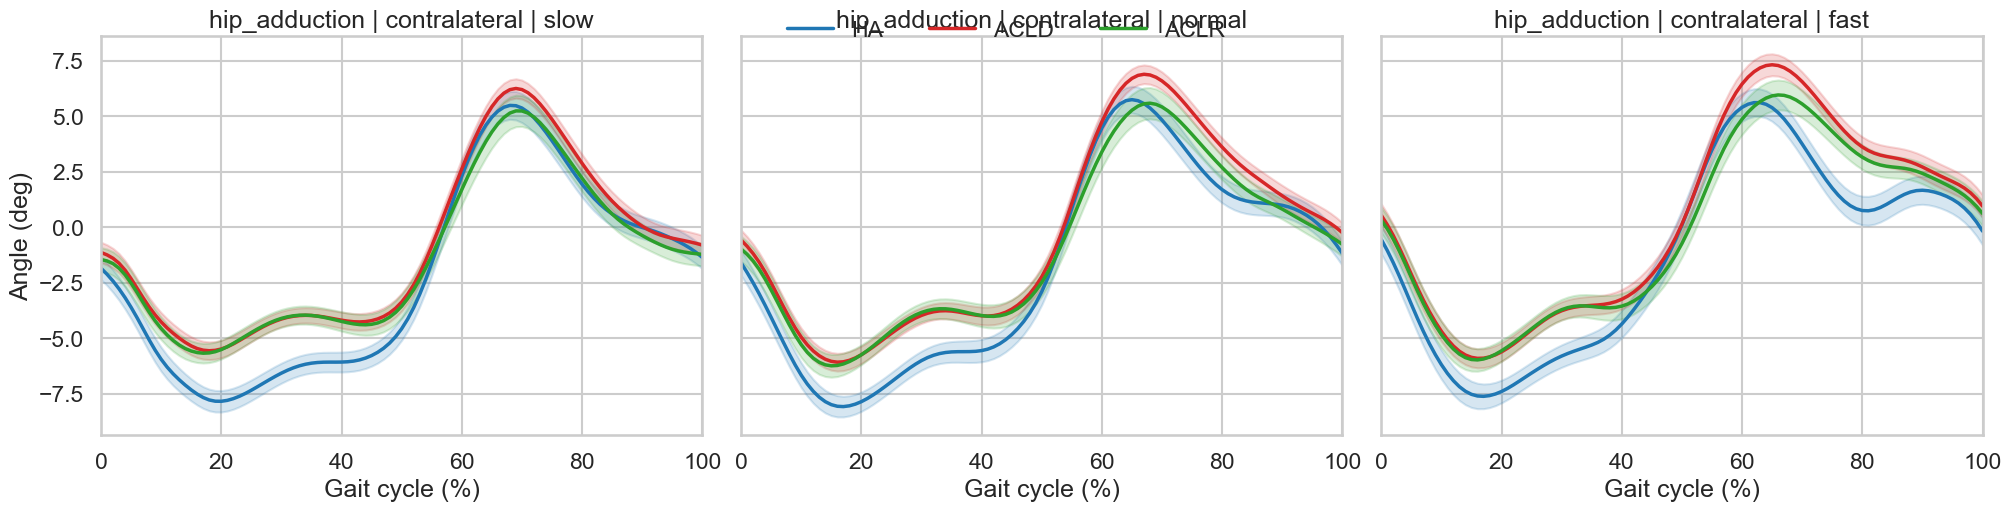

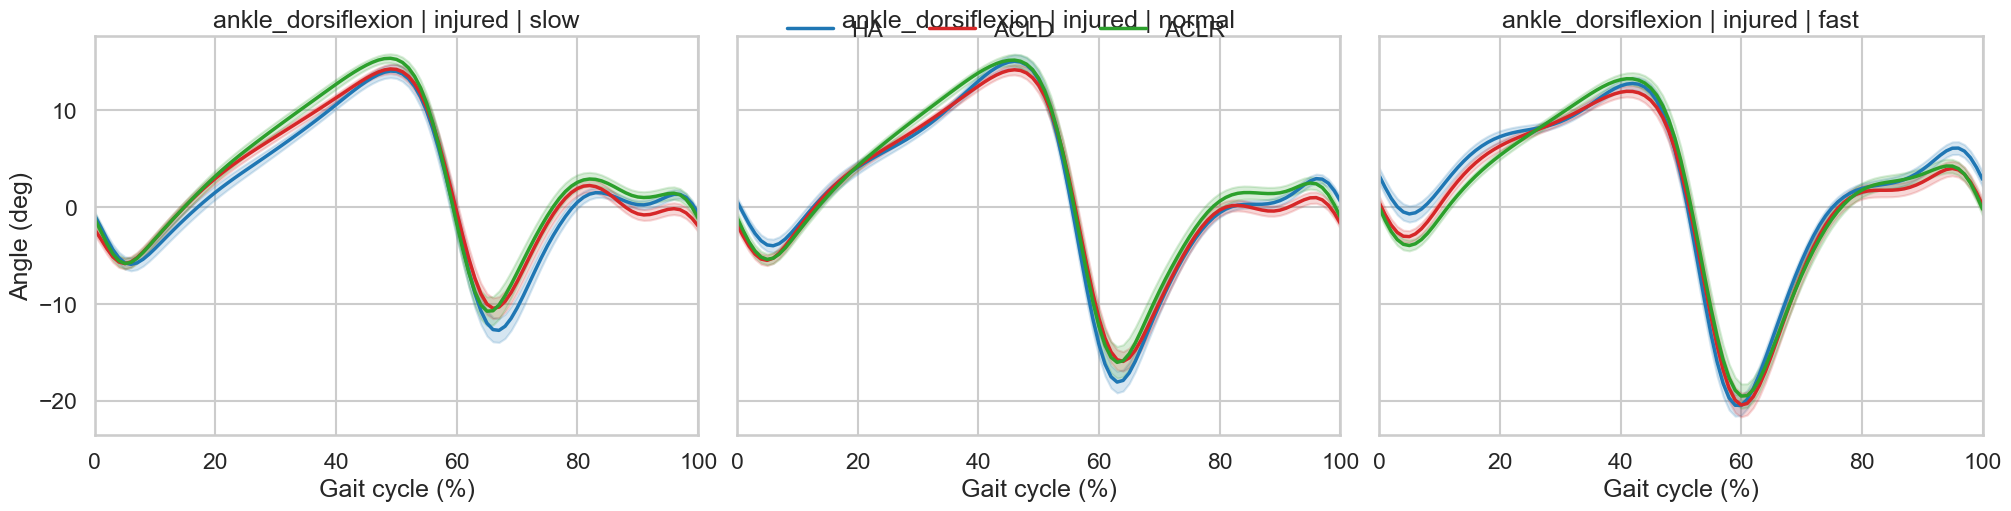

In [8]:
plot_feature_waveforms('knee_flexion', 'injured')
plot_feature_waveforms('knee_flexion', 'contralateral')
plot_feature_waveforms('knee_adduction', 'injured')
plot_feature_waveforms('hip_adduction', 'contralateral')
plot_feature_waveforms('ankle_dorsiflexion', 'injured')

## 3. Paired ACLD vs ACLR 결과
같은 사람에서 ACLD와 ACLR가 모두 존재하는 subset에 대해서는 paired SPM을 별도로 수행했다.

In [9]:
paired_sig = spm[(spm['comparison_scope'] == 'paired_acl') & (spm['significant_fdr'])][[
    'speed', 'side_basis', 'feature', 'test_p_fdr', 'start_pct', 'end_pct', 'effect_size', 'mean_diff'
]].sort_values(['test_p_fdr', 'speed', 'feature'])
paired_sig

,speed,side_basis,feature,test_p_fdr,start_pct,end_pct,effect_size,mean_diff
323,normal,contralateral,knee_adduction,0.000255,12.0,30.0,0.862712,0.562973
299,slow,contralateral,hip_flexion,0.002382,0.0,18.0,0.675320,3.240004
300,slow,contralateral,hip_flexion,0.002382,83.0,100.0,0.676682,2.598451
333,fast,injured,knee_flexion,0.003904,34.0,50.0,0.782964,2.263550
334,fast,injured,knee_flexion,0.003904,90.0,98.0,0.739929,2.952827
312,normal,injured,knee_flexion,0.004198,32.0,46.0,0.689104,2.517160
313,normal,injured,knee_flexion,0.004198,92.0,99.0,0.704989,2.576476
340,fast,contralateral,hip_flexion,0.004596,3.0,17.0,0.637696,2.709563
341,fast,contralateral,hip_flexion,0.004596,95.0,100.0,0.598197,2.461437
316,normal,contralateral,ankle_dorsiflexion,0.004596,0.0,2.0,0.657038,1.774819


## 4. LMM 결과
SPM에서 살아남은 구간과 임상적으로 해석 가능한 파생 summary feature를 사용해
`feature ~ group * speed + age + sex + (1|person_id)` 형태의 LMM을 적합했다.
공변량이 부족한 경우에는 covariate 없는 대체 모델도 허용했다.

In [10]:
lmm_primary_sig = lmm[(lmm['analysis_subset'] == 'primary') & ((lmm['p_group_main_sig_fdr'].fillna(False)) | (lmm['p_interaction_sig_fdr'].fillna(False)))].copy()
lmm_primary_sig[['feature', 'p_group_main', 'p_group_main_fdr', 'p_interaction', 'p_interaction_fdr', 'mean_HA', 'mean_ACLD', 'mean_ACLR']].sort_values(['p_group_main_fdr', 'p_interaction_fdr']).head(30)

,feature,p_group_main,p_group_main_fdr,p_interaction,p_interaction_fdr,mean_HA,mean_ACLD,mean_ACLR
155,knee_adduction_injured_spm_region_mean,2.916373e-10,6.765985e-08,5.048050e-10,1.171148e-07,-0.089365,-1.461867,-1.196518
194,knee_flexion_injured_peak_min,1.721880e-09,1.997381e-07,4.158144e-02,1.608344e-01,-0.870500,-0.519547,2.333773
196,knee_flexion_injured_rom,1.729840e-08,1.337743e-06,1.981269e-04,6.566493e-03,60.385897,60.851088,54.611741
199,knee_flexion_injured_terminal_stance_mean,2.093164e-07,1.214035e-05,2.523001e-02,1.330310e-01,6.827253,8.998825,11.120701
127,knee_adduction_contralateral_mid_stance_mean,6.130992e-07,2.844780e-05,4.210138e-01,5.113885e-01,-0.639721,-0.467636,-0.078170
174,knee_flexion_contralateral_rom,8.837676e-06,2.562926e-04,2.814212e-04,7.121216e-03,59.967275,63.297660,62.417500
211,knee_int_rotation_contralateral_mid_stance_mean,6.931417e-06,2.562926e-04,2.150068e-01,3.778907e-01,0.390758,0.902933,1.588313
185,knee_flexion_diff_rom,8.492521e-06,2.562926e-04,4.510325e-01,5.284826e-01,0.418622,-2.446572,-7.805759
205,knee_flexion_lsi_rom,1.215872e-05,3.134249e-04,4.377842e-01,5.227907e-01,100.919032,96.307951,87.566012
183,knee_flexion_diff_peak_min,5.358742e-05,1.243228e-03,2.443303e-01,3.882509e-01,0.415204,2.002299,4.286211


## 5. Feature ranking
LMM 또는 SPM에서 살아남은 feature를 대상으로 grouped CV 기반 multinomial elastic-net을 사용해
그룹 구분에 기여도가 큰 요소를 순위화했다.

In [11]:
top_rank = rank.head(15).copy()
top_rank

,feature,importance,rank,best_params,cv_macro_f1,cv_accuracy
0,knee_adduction_injured_spm_region_mean,0.303691,1,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
1,knee_flexion_diff_terminal_stance_mean,0.254984,2,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
2,hip_adduction_contralateral_spm_region_mean,0.226278,3,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
3,knee_flexion_diff_rom,0.184674,4,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
4,ankle_dorsiflexion_diff_loading_response_mean,0.181192,5,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
5,knee_flexion_injured_peak_min,0.177233,6,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
6,ankle_dorsiflexion_injured_loading_response_mean,0.161018,7,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
7,knee_adduction_injured_mid_stance_mean,0.154540,8,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
8,knee_flexion_lsi_rom,0.154425,9,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263
9,ankle_adduction_contralateral_peak_min_pct,0.142460,10,"{'clf__C': 0.1, 'clf__l1_ratio': 0.3}",0.597531,0.605263


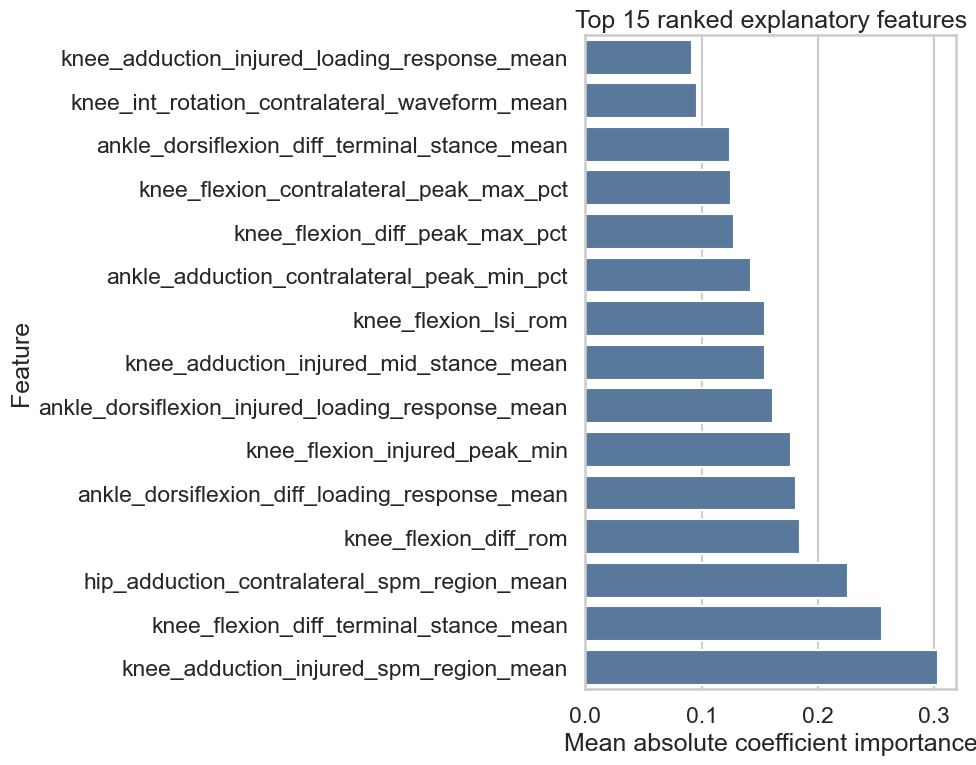

In [12]:
plt.figure(figsize=(10, 8))
sns.barplot(data=top_rank.sort_values('importance', ascending=True), x='importance', y='feature', color='#4c78a8')
plt.title('Top 15 ranked explanatory features')
plt.xlabel('Mean absolute coefficient importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Validation / sensitivity
분석 파이프라인은 joint mapping, sign convention, 속도별 ROM 경향,
그리고 full-trial vs mid-trial sensitivity를 함께 기록한다.

In [13]:
val

,check,item,expected,observed,passed
0,joint_mapping,jointAngle_42:hip_adduction,Right Hip Abduction/Adduction,Right Hip Abduction/Adduction,True
1,joint_mapping,jointAngle_43:hip_int_rotation,Right Hip Internal/External Rotation,Right Hip Internal/External Rotation,True
2,joint_mapping,jointAngle_44:hip_flexion,Right Hip Flexion/Extension,Right Hip Flexion/Extension,True
3,joint_mapping,jointAngle_45:knee_adduction,Right Knee Abduction/Adduction,Right Knee Abduction/Adduction,True
4,joint_mapping,jointAngle_46:knee_int_rotation,Right Knee Internal/External Rotation,Right Knee Internal/External Rotation,True
5,joint_mapping,jointAngle_47:knee_flexion,Right Knee Flexion/Extension,Right Knee Flexion/Extension,True
6,joint_mapping,jointAngle_48:ankle_adduction,Right Ankle Abduction/Adduction,Right Ankle Abduction/Adduction,True
7,joint_mapping,jointAngle_49:ankle_int_rotation,Right Ankle Internal/External Rotation,Right Ankle Internal/External Rotation,True
8,joint_mapping,jointAngle_50:ankle_dorsiflexion,Right Ankle Dorsiflexion/Plantarflexion,Right Ankle Dorsiflexion/Plantarflexion,True
9,joint_mapping,jointAngle_54:hip_adduction,Left Hip Abduction/Adduction,Left Hip Abduction/Adduction,True


In [14]:
sens[sens['same_fdr_decision'] == False]

,speed,side_basis,feature,full_p_raw,full_p_fdr,full_sig_fdr,mid_p_raw,mid_p_fdr,mid_sig_fdr,same_fdr_decision
43,normal,contralateral,knee_flexion,0.025973,0.08141,False,0.01285,0.043367,True,False


## 7. 해석 메모
이 결과에서 가장 일관되게 나타나는 패턴은 다음과 같다.

- primary waveform 결과의 중심은 무릎(`knee_flexion`, `knee_adduction`)이었다.
- post-hoc에서는 `HA vs ACLR` 차이가 가장 자주 유의했고, `HA vs ACLD`는 상대적으로 제한적이었다.
- LMM과 ranking에서도 knee-derived feature가 상위권을 지배했다.
- 일부 발목 배측굴곡과 contralateral hip adduction도 보조적인 설명 변수로 나타났다.
- sensitivity에서는 대부분 동일한 결론을 보였지만, `normal / contralateral / knee_flexion`은 full과 midtrial의 FDR 결정이 달랐다.